<a href="https://colab.research.google.com/github/ReshmaAjil/Board_Ready_Financial_Review/blob/main/Board_Ready_Financial_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Month,Revenue,Expenses,P&L,Revenue_MoM_%
0,2024-01-01,120000,82000,38000,NaN
1,2024-02-01,125000,83000,42000,4.166667
2,2024-03-01,130000,84500,45500,4.000000
3,2024-04-01,135000,86000,49000,3.846154
4,2024-05-01,132000,87000,45000,-2.222222
5,2024-06-01,128000,88000,40000,-3.030303
6,2024-07-01,126000,105000,21000,-1.562500
7,2024-08-01,129000,89000,40000,2.380952
8,2024-09-01,133000,90000,43000,3.100775
9,2024-10-01,138000,91500,46500,3.759398


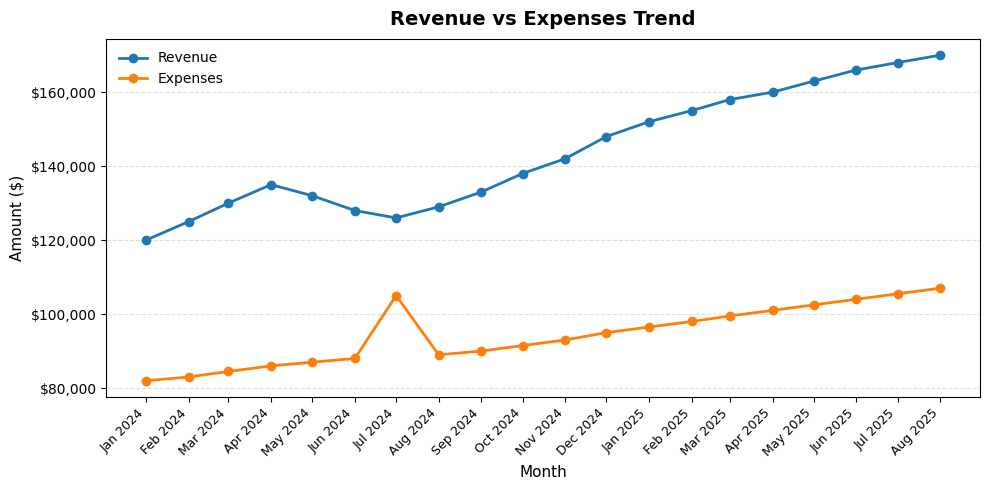

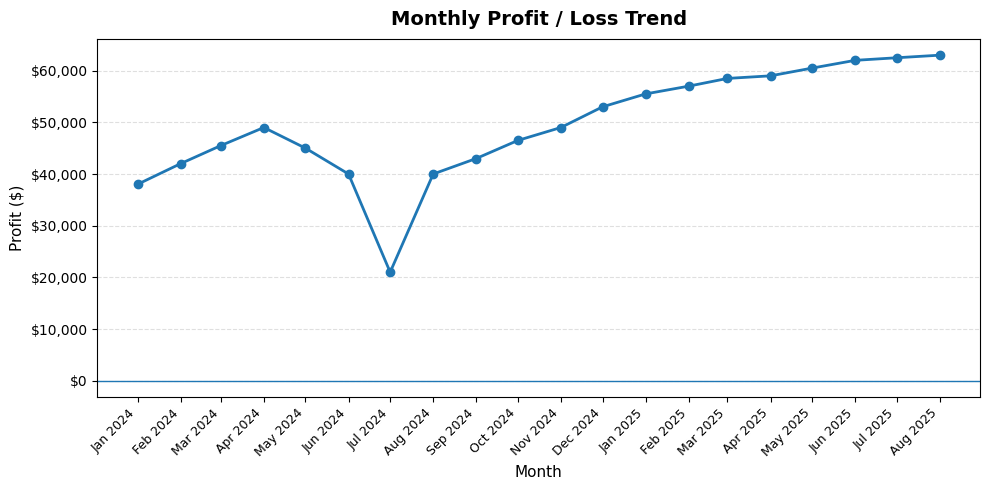

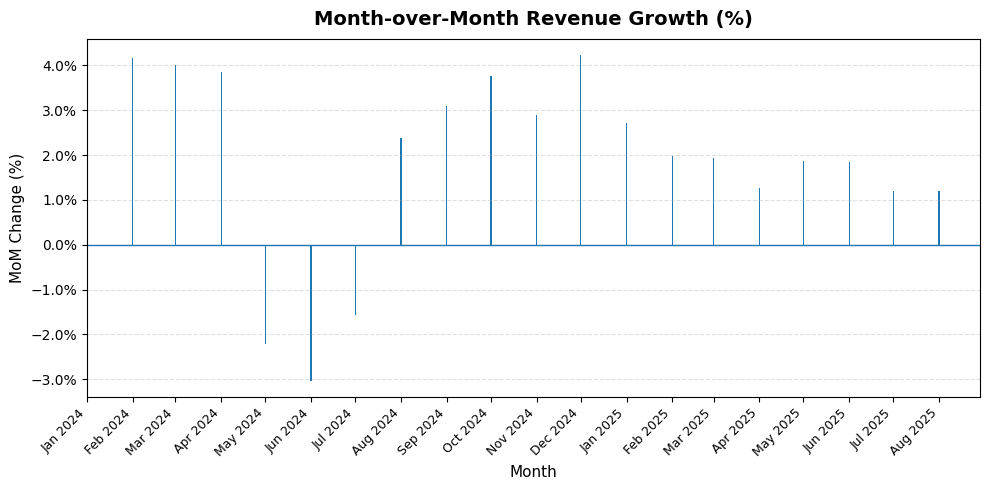

Saved files:
- revenue_expense_trend.png
- pl_trend.png
- mom_revenue_growth.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# =========================
# 1. Create realistic data
# =========================
df = pd.DataFrame({
    "Month": pd.date_range(start="2024-01-01", periods=20, freq="MS"),
    "Revenue": [
        120000, 125000, 130000, 135000, 132000,
        128000, 126000, 129000, 133000, 138000,
        142000, 148000, 152000, 155000, 158000,
        160000, 163000, 166000, 168000, 170000
    ],
    "Expenses": [
        82000, 83000, 84500, 86000, 87000,
        88000, 105000, 89000, 90000, 91500,
        93000, 95000, 96500, 98000, 99500,
        101000, 102500, 104000, 105500, 107000
    ]
})

# =========================
# 2. Derived metrics
# =========================
df["P&L"] = df["Revenue"] - df["Expenses"]
df["Revenue_MoM_%"] = df["Revenue"].pct_change() * 100

display(df)

# Common X-axis labels
x_labels = df["Month"].dt.strftime("%b %Y")

# =========================
# 3. Chart 1: Revenue vs Expenses
# =========================
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df["Month"], df["Revenue"], marker="o", linewidth=2, label="Revenue")
ax.plot(df["Month"], df["Expenses"], marker="o", linewidth=2, label="Expenses")

ax.set_title("Revenue vs Expenses Trend", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Amount ($)", fontsize=11)

ax.set_xticks(df["Month"])
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("revenue_expense_trend.png")
plt.show()

# =========================
# 4. Chart 2: Profit & Loss
# =========================
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df["Month"], df["P&L"], marker="o", linewidth=2)

ax.axhline(0, linewidth=1)
ax.set_title("Monthly Profit / Loss Trend", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Profit ($)", fontsize=11)

ax.set_xticks(df["Month"])
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("pl_trend.png")
plt.show()

# =========================
# 5. Chart 3: MoM Revenue Growth
# =========================
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(df["Month"], df["Revenue_MoM_%"])

ax.axhline(0, linewidth=1)
ax.set_title("Month-over-Month Revenue Growth (%)", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("MoM Change (%)", fontsize=11)

ax.set_xticks(df["Month"])
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.1f}%'))

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("mom_revenue_growth.png")
plt.show()

print("Saved files:")
print("- revenue_expense_trend.png")
print("- pl_trend.png")
print("- mom_revenue_growth.png")